<a href="https://colab.research.google.com/github/ShreyasD21/Analy/blob/main/Analytics_Club_Induction_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
matches = pd.read_csv('/content/drive/MyDrive/Dataset1.csv')
deliveries = pd.read_csv('/content/drive/MyDrive/IPL_Ball_by_Ball_2008_2022.csv')

In [ ]:
matches.shape

(950, 20)

In [ ]:
deliveries.shape

(225954, 17)

In [ ]:
matches['Team1'].value_counts()  #Rising Pune Supergiants and Rising Pune Supergiant are the same team

,count
Team1,
Royal Challengers Bangalore,126
Mumbai Indians,112
Chennai Super Kings,111
Kolkata Knight Riders,105
Kings XI Punjab,92
Rajasthan Royals,89
Delhi Daredevils,85
Sunrisers Hyderabad,69
Deccan Chargers,39


In [ ]:
print(matches['Team2'].value_counts())
print("-"*40)

Team2
Mumbai Indians                 119
Kolkata Knight Riders          118
Rajasthan Royals               103
Royal Challengers Bangalore    100
Kings XI Punjab                 98
Chennai Super Kings             97
Sunrisers Hyderabad             83
Delhi Daredevils                76
Deccan Chargers                 36
Delhi Capitals                  34
Pune Warriors                   23
Gujarat Lions                   14
Punjab Kings                    10
Gujarat Titans                   9
Rising Pune Supergiant           9
Lucknow Super Giants             7
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Name: count, dtype: int64
----------------------------------------


**DATA** **CLEANING**

In [ ]:
Season_new = {'2007/08': '2008',
              '2009/10': '2010',
              '2020/21': '2020'
}

matches['Season'] = matches['Season'].replace(Season_new)
print(matches['Season'].unique())

['2022' '2021' '2020' '2019' '2018' '2017' '2016' '2015' '2014' '2013'
 '2012' '2011' '2010' '2009' '2008']


In [ ]:
Team_Corrections = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'}
matches.replace(Team_Corrections, inplace = True)
deliveries.replace(Team_Corrections, inplace = True)

In [ ]:
matches['Team1'].value_counts()

,count
Team1,
Royal Challengers Bangalore,126
Delhi Capitals,114
Mumbai Indians,112
Chennai Super Kings,111
Punjab Kings,110
Kolkata Knight Riders,105
Rajasthan Royals,89
Sunrisers Hyderabad,69
Deccan Chargers,39


In [ ]:
print(matches.isna().sum())

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64


In [ ]:
null = matches[matches['WinningTeam'].isnull()]
null                                             #Matches that were not completed

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
205,1178424,Bengaluru,2019-04-30,2019,49,Royal Challengers Bangalore,Rajasthan Royals,M.Chinnaswamy Stadium,Rajasthan Royals,field,NaN,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'AB de Villiers', 'MP Stoinis', 'H...","['SV Samson', 'LS Livingstone', 'AM Rahane', '...",NJ Llong,UV Gandhe
437,829813,Bangalore,2015-05-17,2015,55,Royal Challengers Bangalore,Delhi Capitals,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,NaN,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'CH Gayle', 'AB de Villiers', 'Man...","['Q de Kock', 'SS Iyer', 'JP Duminy', 'Yuvraj ...",HDPK Dharmasena,K Srinivasan
464,829763,Bangalore,2015-04-29,2015,29,Royal Challengers Bangalore,Rajasthan Royals,M Chinnaswamy Stadium,Rajasthan Royals,field,NaN,NaN,NoResults,NaN,NaN,NaN,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'Man...","['AM Rahane', 'SR Watson', 'SPD Smith', 'KK Na...",JD Cloete,PG Pathak
708,501265,Delhi,2011-05-21,2011,68,Delhi Capitals,Pune Warriors,Feroz Shah Kotla,Delhi Capitals,bat,NaN,NaN,NoResults,NaN,NaN,NaN,"['NV Ojha', 'DA Warner', 'MS Wade', 'CA Ingram...","['MK Pandey', 'JP Faulkner', 'SC Ganguly', 'RV...",SS Hazare,RJ Tucker


In [ ]:
matches.dropna(subset=['WinningTeam'], inplace = True)

In [ ]:
matches['method'].value_counts()

,count
method,
D/L,19


In [ ]:
matches['City'] = matches['City'].fillna('Unknown')
matches['method'] = matches['method'].fillna('Non D/L')    #Matches which didn't have rain, so D/L method was not used

In [ ]:
matches['method'].value_counts()

,count
method,
Non D/L,927
D/L,19


In [ ]:
matches["Venue"].unique()

array(['Narendra Modi Stadium, Ahmedabad', 'Eden Gardens, Kolkata',
       'Wankhede Stadium, Mumbai', 'Brabourne Stadium, Mumbai',
       'Dr DY Patil Sports Academy, Mumbai',
       'Maharashtra Cricket Association Stadium, Pune',
       'Dubai International Cricket Stadium', 'Sharjah Cricket Stadium',
       'Zayed Cricket Stadium, Abu Dhabi', 'Arun Jaitley Stadium, Delhi',
       'MA Chidambaram Stadium, Chepauk, Chennai', 'Sheikh Zayed Stadium',
       'Rajiv Gandhi International Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'MA Chidambaram Stadium',
       'Punjab Cricket Association IS Bindra Stadium', 'Wankhede Stadium',
       'M.Chinnaswamy Stadium', 'Arun Jaitley Stadium', 'Eden Gardens',
       'Sawai Mansingh Stadium',
       'Maharashtra Cricket Association Stadium',
       'Holkar Cricket Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Green Park',
       'Punjab Cricket A

In [ ]:
Venue_new = {'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
             'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
             'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
             'Eden Gardens, Kolkata': 'Eden Gardens',
             'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
             'Feroz Shah Kotla': 'Arun Jaitley Stadium', # It is the same ground
             'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
             'Zayed Cricket Stadium, Abu Dhabi': 'Sheikh Zayed Stadium',
             'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium'}
matches['Venue'] = matches['Venue'].replace(Venue_new)

**Statistical Visualization**

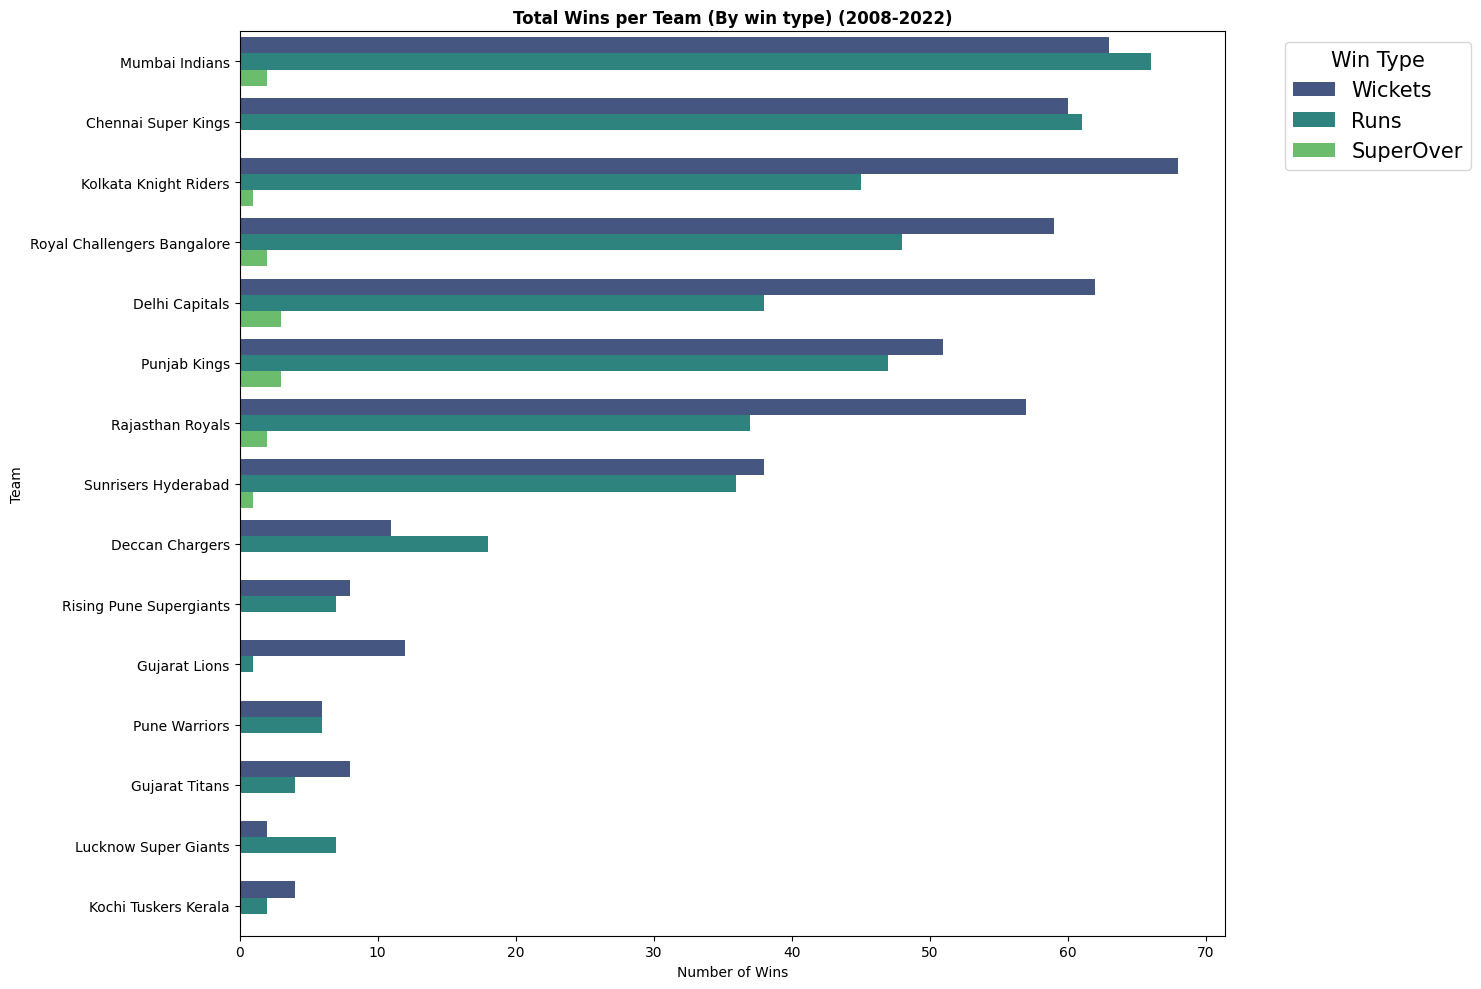

In [ ]:
#Bar Chart
plt.figure(figsize=(15, 10))
sns.countplot(y='WinningTeam',
              hue = 'WonBy',
              data=matches,
              order=matches['WinningTeam'].value_counts().index,
              palette='viridis')
plt.title('Total Wins per Team (By win type) (2008-2022)', fontweight = 'bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.legend(title='Win Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 15, title_fontsize = 15) #Moving the legend outside the plot area so that it doesn't cover the data

plt.tight_layout()
plt.savefig('team wins.png', dpi=150)
plt.show()

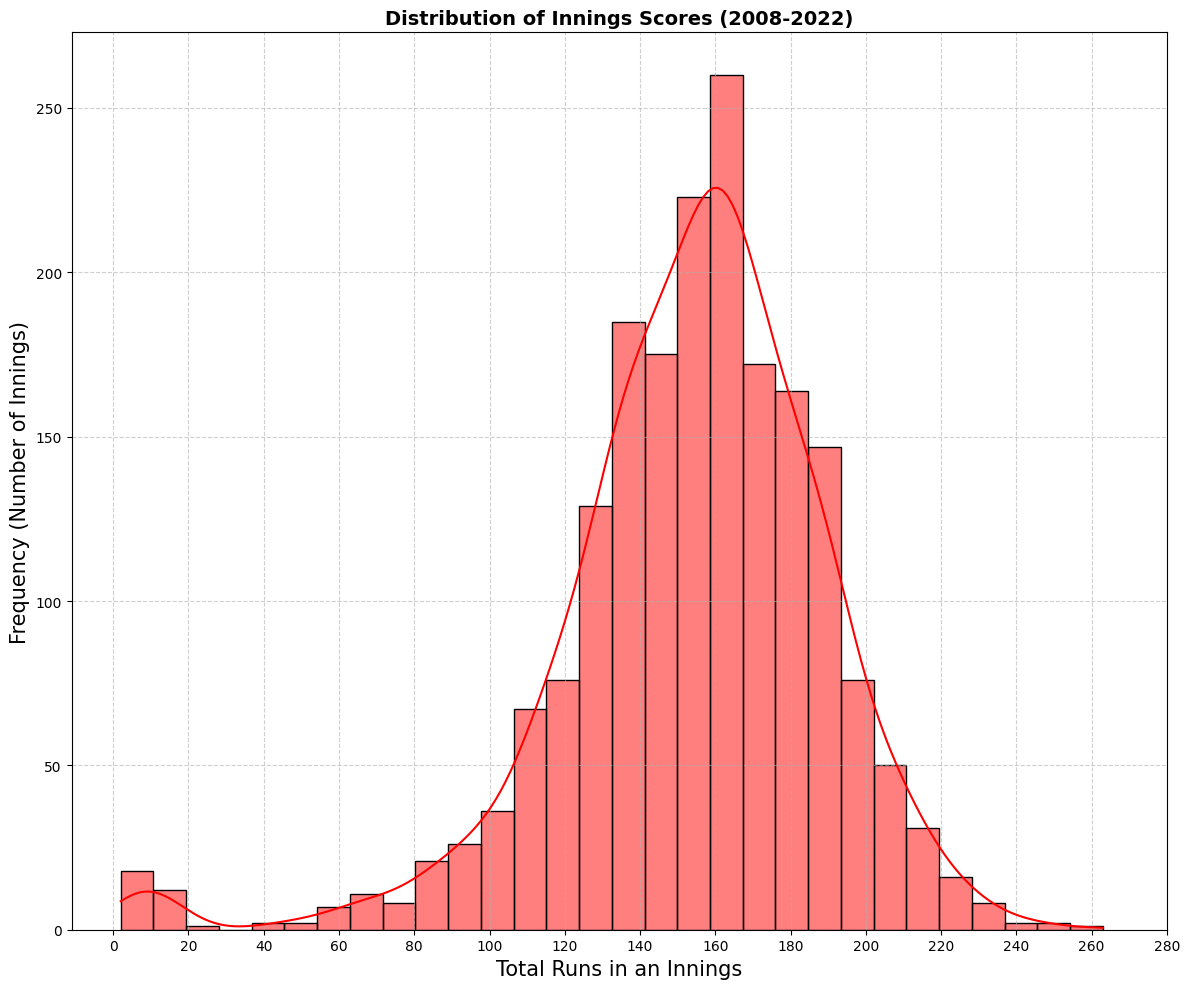

In [ ]:
#Histogram
inning_scores = deliveries.groupby(['ID', 'innings'])['total_run'].sum().reset_index()
plt.figure(figsize = (12,10))
sns.histplot(inning_scores['total_run'], bins=30, kde=True, color='red')
plt.title('Distribution of Innings Scores (2008-2022)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Total Runs in an Innings', fontsize = 15)
plt.xticks(np.arange(0,300,20))
plt.ylabel('Frequency (Number of Innings)', fontsize = 15)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('score distribution.png', dpi = 150)
plt.show()

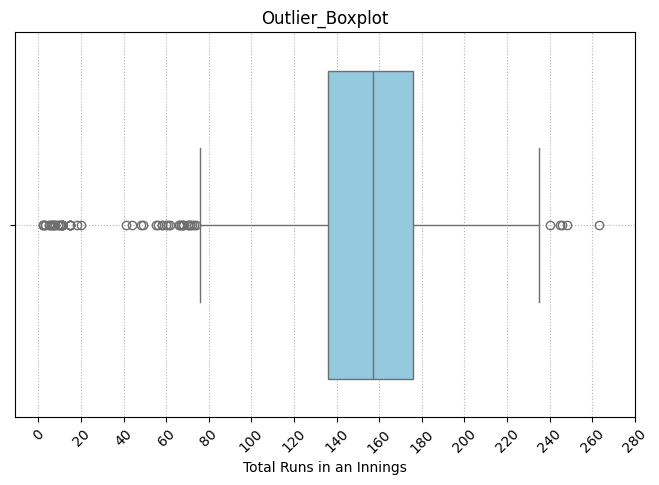

In [ ]:
#Box Plot
Inning_Scores = deliveries.groupby(['ID', 'innings'])['total_run'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.boxplot(x=Inning_Scores['total_run'], color='skyblue')
plt.title('Outlier_Boxplot')
plt.xlabel('Total Runs in an Innings')
plt.xticks(np.arange(0,300,20),rotation = 45)
plt.grid(True, linestyle = 'dotted', alpha = 0.95)

plt.savefig('outlier boxplot.png', dpi=150)
plt.show()

In [ ]:
#Interquartile Range (IQR) fence method
Q1 = Inning_Scores['total_run'].quantile(0.25)
Q3 = Inning_Scores['total_run'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
IQR_outliers = Inning_Scores[(Inning_Scores['total_run'] < lower_whisker) |
                         (Inning_Scores['total_run'] > upper_whisker)]
print(f"Upper Limit: {upper_whisker}")
print(f"Lower Limit: {lower_whisker}")
print(f"Number of Outliers found by IQR: {len(IQR_outliers)}")

Upper Limit: 236.0
Lower Limit: 76.0
Number of Outliers found by IQR: 61


In [ ]:
#The Z-Score Method (|z| > 3)
z = np.abs(stats.zscore(inning_scores['total_run']))
Z_outliers = inning_scores[(z > 3)]                  # where Z-score is greater than 3
print(f"Number of Outliers found by Z-Score: {len(Z_outliers)}")

Number of Outliers found by Z-Score: 34


In [ ]:
#The common outliers
common_outliers = pd.merge(IQR_outliers, Z_outliers, on=['ID', 'innings', 'total_run'])

iqr_only = IQR_outliers[~IQR_outliers['ID'].isin(Z_outliers['ID'])]
print(f"Total IQR Outliers: {len(IQR_outliers)}")
print(f"Total Z-Score Outliers: {len(Z_outliers)}")
print(f"Common Outliers (The 'Extreme' cases): {len(common_outliers)}")
print("-"*45)

Total IQR Outliers: 61
Total Z-Score Outliers: 34
Common Outliers (The 'Extreme' cases): 34
---------------------------------------------


Outlier Reconciliation:
In our analysis, we found that the IQR method identifies 61 outliers, whereas the Z-score method only  
identifies 34 outliers. After reviewing the matches, it is known that these are genuine matches
played and not data errors. Hence, these matches will not be excluded from the dataset as removing them would
lose important historical context for the model.

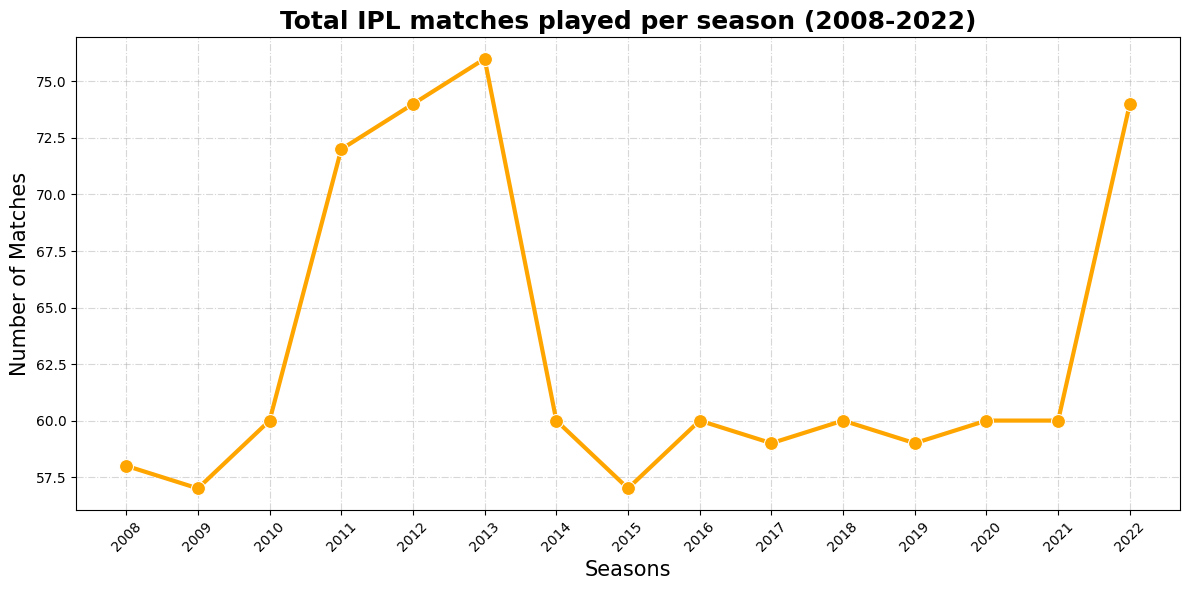

In [ ]:
#Line Chart
matches_per_season = matches.groupby('Season').size()
plt.figure(figsize = (12,6))
sns.lineplot(x = matches_per_season.index,
             y = matches_per_season.values,
             marker = 'o',
             markersize = 10,
             color = 'orange',
             linewidth = 3)
plt.title('Total IPL matches played per season (2008-2022)',fontsize = 18, fontweight = 'bold')
plt.xlabel('Seasons',fontsize = 15)
plt.ylabel('Number of Matches',fontsize = 15)
plt.xticks(rotation=45)
plt.grid(True, linestyle='dashdot', alpha=0.5)
plt.tight_layout()
plt.savefig('matches_per_season.png', dpi = 150)
plt.show()

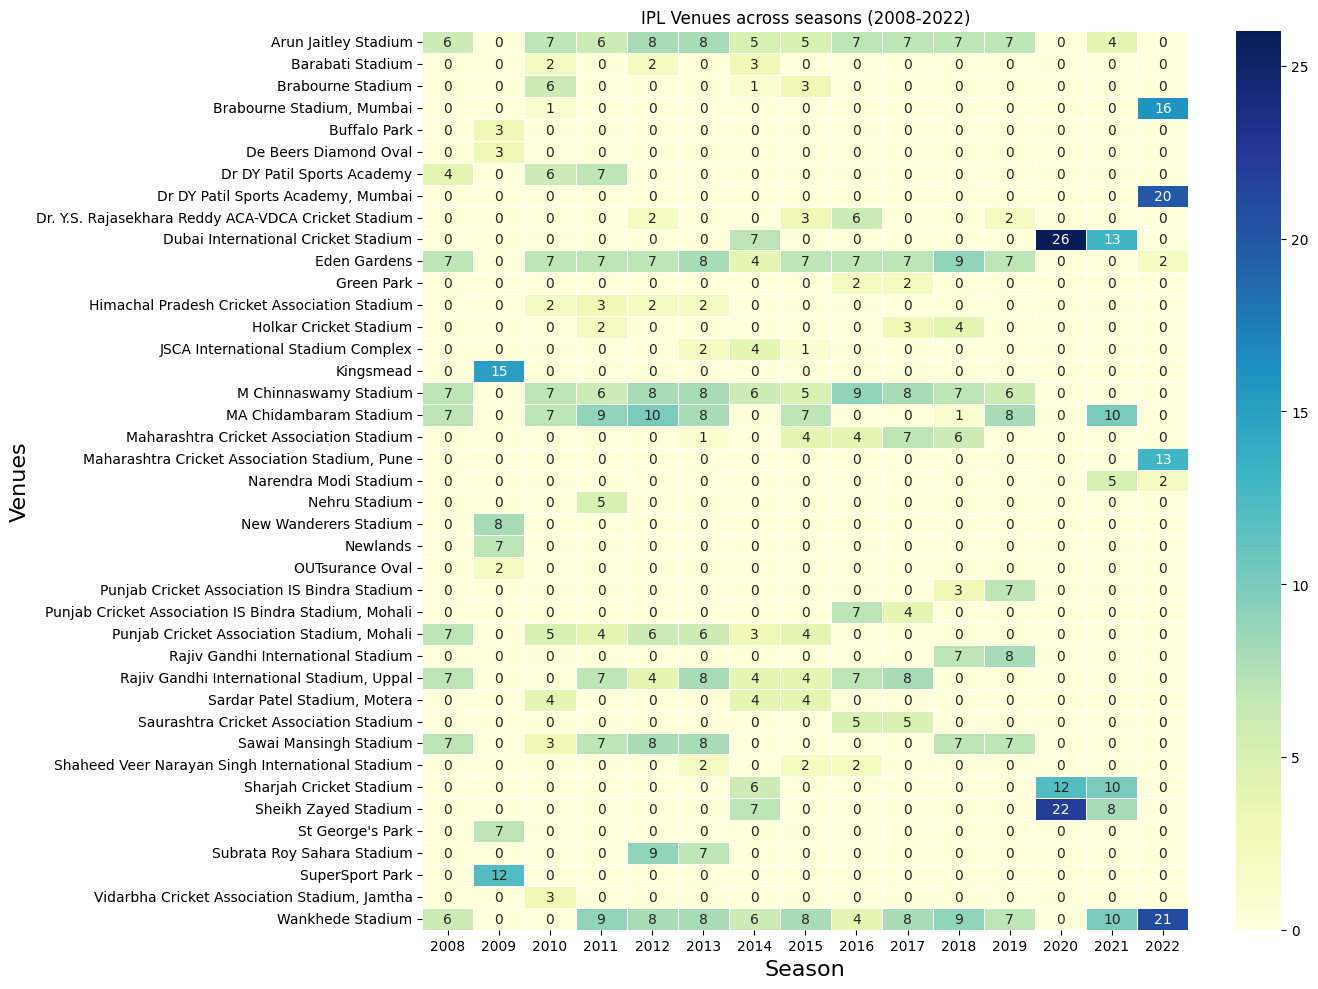

In [ ]:
#Heatmap
Venue_Season = matches.pivot_table(index='Venue',
                                   columns='Season',
                                   values='ID',
                                   aggfunc='count').fillna(0)
plt.figure(figsize = (14,10))
sns.heatmap(Venue_Season,
           annot = True,
           cmap = 'YlGnBu',
           fmt = 'g',
           linewidths = 0.7)
plt.title('IPL Venues across seasons (2008-2022)')
plt.xlabel('Season', fontsize = 16)
plt.ylabel('Venues', fontsize = 16)

plt.tight_layout()
plt.savefig('venue heatmap.png', dpi = 150)
plt.show()

In [ ]:
print(matches['TossDecision'].value_counts())

TossDecision
field    596
bat      350
Name: count, dtype: int64


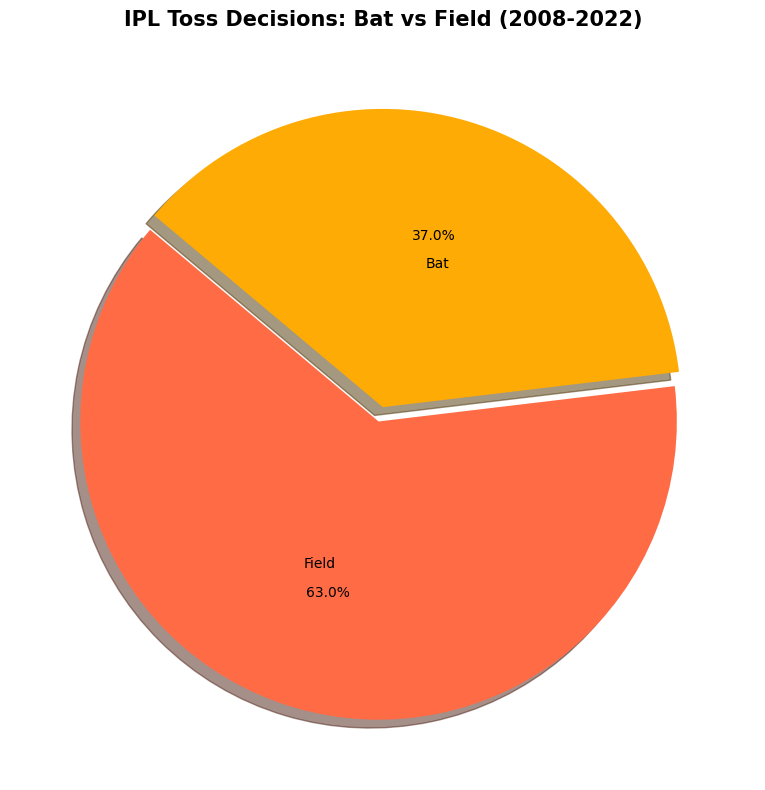

In [ ]:
#Pie Chart
Toss_decisions = matches['TossDecision'].value_counts()
plt.figure(figsize = (14,8))
colors = ['#FF6B45', '#FFAB05']
labels = ['Field', 'Bat']
plt.pie(Toss_decisions,
        labels = labels,
        labeldistance = 0.5,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0),
        shadow=True)
plt.title('IPL Toss Decisions: Bat vs Field (2008-2022)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('toss pie.png', dpi = 150)
plt.show()

**MODEL CONSTRUCTION**

In [ ]:
#Encoding categorical features and defining binary target variable (Team batting first wins!!)
#Binary column: 1 if the team batting first wins and 0 if they don't.
from sklearn.preprocessing import LabelEncoder
matches_new = matches.copy()
matches_new['bat_first_won'] = (matches_new['WinningTeam'].str.strip() ==
                                matches_new['Team1'].str.strip()).astype(int)
print(matches_new['bat_first_won'].value_counts())
le = LabelEncoder()
categorical_columns = ['Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision']
for col in categorical_columns:
    matches_new[col] = le.fit_transform(matches_new[col].astype(str))
print("Encoding Complete. Sample values:", matches_new['Venue'].head())

bat_first_won
1    480
0    466
Name: count, dtype: int64
Encoding Complete. Sample values: 0    20
1    20
2    10
3    10
4    40
Name: Venue, dtype: int64


In [ ]:
#Stratified 80/20 train-test split
X = matches_new[['Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision']]
y = matches_new['bat_first_won']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size = 0.2,    # to make an 80-20 split
                                                   random_state = 42,  # to make results reproducible
                                                   stratify = y        # to ensure the data split is balanced
                                                   )
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 756
Testing set size: 190


In [ ]:
#Building the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)
y_prediction = log_reg.predict(X_test)
y_probability = log_reg.predict_proba(X_test)[:, 1]      #necessary for ROC curve

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

train_prediction = log_reg.predict(X_train)
test_prediction = log_reg.predict(X_test)

# For Training Data
train_metrics = {
    'Dataset': 'Training',
    'Accuracy': accuracy_score(y_train, train_prediction),
    'Precision': precision_score(y_train, train_prediction),
    'Recall': recall_score(y_train, train_prediction),
    'F1-Score': f1_score(y_train, train_prediction)
}

# For Test Data
test_metrics = {
    'Dataset': 'Test',
    'Accuracy': accuracy_score(y_test, test_prediction),
    'Precision': precision_score(y_test, test_prediction),
    'Recall': recall_score(y_test, test_prediction),
    'F1-Score': f1_score(y_test, test_prediction)
}

# Comparison Table
comparison = pd.DataFrame([train_metrics, test_metrics])
print("--- Model Performance Comparison ---")
print(comparison.to_string(index=False))
print("-"*50)

--- Model Performance Comparison ---
 Dataset  Accuracy  Precision   Recall  F1-Score
Training  0.550265   0.555838 0.570312  0.562982
    Test  0.515789   0.518519 0.583333  0.549020
--------------------------------------------------


As we can see from the summary table, the numbers obtained by the model from the training dataset is approximately equal to the numbers obtained by the model from the testing dataset. This means that the model is generalizing accurately.


<Figure size 1000x800 with 0 Axes>

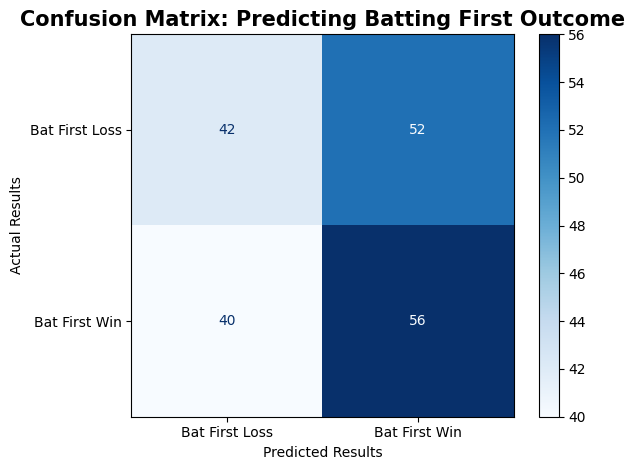

In [ ]:
#making the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
con_mat = confusion_matrix(y_test, y_prediction)    # For matrix data
disp = ConfusionMatrixDisplay(confusion_matrix = con_mat, display_labels=['Bat First Loss', 'Bat First Win'])   #Creating the display for the matrix (0 = Loss and 1 = Won)
plt.figure(figsize=(10,8))
disp.plot(cmap = 'Blues', values_format = 'd')   # 'd' ensures whole numbers not decimals
plt.title('Confusion Matrix: Predicting Batting First Outcome', fontsize = 15, fontweight = 'bold')
plt.xlabel('Predicted Results')
plt.ylabel('Actual Results')
plt.grid(False)

plt.tight_layout()
plt.savefig('confusion matrix.png', dpi = 150)
plt.show()

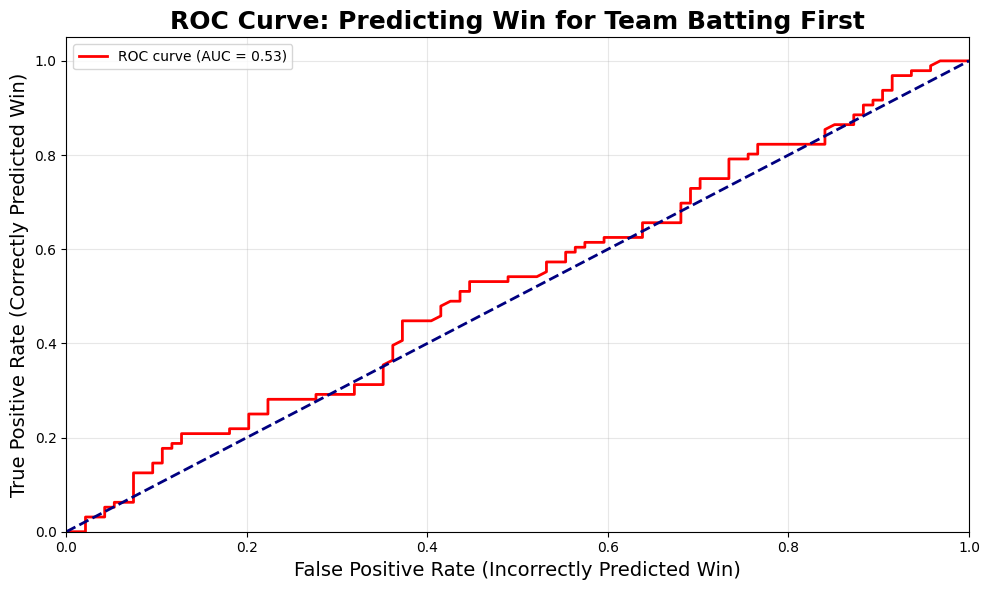

AUC score: 0.53


In [ ]:
#Creating the ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_probability)
auc_value = roc_auc_score(y_test, y_probability)
plt.figure(figsize = (10,6))
plt.plot(fpr, tpr, color = 'Red', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='dashed')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrectly Predicted Win)', fontsize=14)
plt.ylabel('True Positive Rate (Correctly Predicted Win)', fontsize=14)
plt.title('ROC Curve: Predicting Win for Team Batting First', fontsize=18, fontweight='bold')
plt.legend(loc="upper left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc curve.png', dpi = 150)
plt.show()
print(f"AUC score: {auc_value:.2f}")

In [ ]:
#Statistical Hypothesis Testing
from scipy.stats import chi2_contingency
matches['toss_winner_won'] = (matches['TossWinner'] == matches['WinningTeam']).astype(int)
contingency_table = pd.crosstab(matches['TossDecision'], matches['toss_winner_won'])
print(contingency_table)
print("-"*25)

chi2, p , dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")
print("-"*25)
alpha = 0.05
if p < alpha:
    print("Result: Statistically Significant. (The toss decision matters in determining the outcome of the matches! )")
else:
    print("Result: Statistically Insignificant. (The toss decision doesn't clearly determine the outcome).")

toss_winner_won    0    1
TossDecision             
bat              191  159
field            266  330
-------------------------
Chi-Square Statistic: 8.3322
Degrees of Freedom: 1
P-value: 0.0039
-------------------------
Result: Statistically Significant. (The toss decision matters in determining the outcome of the matches! )


1) The relationship between the toss and the outcome of the matches based on the Chi-square test:
The Chi-square test resulted in a p-value of 0.0039 which is well below 0.05(alpha). This confirms that the toss decision and the match outcome are related and the choice to bat/field is a meaningful fator in winning.

2. Using both IQR and Z-score data, we can identify unusual matches (eg. matches having 100 runs as win margin). By reconciling these 2 methods, we can conclude the matches were not simply data errors, ensuring the purity of the training data.

3. The ROC curve is a visualisation of the relation between true positive rate and false positive rate. As my AUC score was 0.53, which is more than 0.5, it indicates that the model has a better chance at deciding whether a team batting first will win or lose as compared to random guessing.

4. My EDA revealed that certain teams have a significantly higher win percentage than others, indicating a historical dominance in the league. Additionally, the venue heatmap showed that specific stadiums host more matches, suggesting that ground dimensions and pitch behavior are critical match variables.

5. There are still some limitations on this model, like it does not consider the weather, player form, player injuries while deciding the outcome of a match. Including the datas like player strike rate on a particular ground etc. can be used to improve the prediction rate of this model.
   